In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from skimage.measure import shannon_entropy

In [5]:
dataset_path = r"F:\work\python\image frequency\images"
output_path = r"F:\work\python\image frequency\processed_dataset_1"

os.makedirs(output_path, exist_ok=True)

In [22]:
image_data = []

for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)
    
    if os.path.isdir(class_folder):
        for img_name in os.listdir(class_folder):
            image_data.append({
                "path": os.path.join(class_folder, img_name),
                "class": class_name
            })

print("Total Images:", len(image_data))

Total Images: 1691


In [23]:
data = []

for item in tqdm(image_data):
    
    img = cv2.imread(item["path"])
    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (224, 224))

    # Features
    mean_intensity = np.mean(gray)

    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size

    entropy = shannon_entropy(gray)

    data.append({
        "path": item["path"],
        "class": item["class"],   # 🔥 KEEP CLASS
        "intensity": mean_intensity,
        "edge_density": edge_density,
        "entropy": entropy
    })

df = pd.DataFrame(data)
print(df.head())

100%|██████████| 1691/1691 [00:04<00:00, 421.41it/s]

                                                path      class   intensity  \
0  F:\work\python\image frequency\images\airplane...  airplanes  175.453105   
1  F:\work\python\image frequency\images\airplane...  airplanes  192.778779   
2  F:\work\python\image frequency\images\airplane...  airplanes  150.174187   
3  F:\work\python\image frequency\images\airplane...  airplanes  132.092096   
4  F:\work\python\image frequency\images\airplane...  airplanes  142.141841   

   edge_density   entropy  
0      0.073043  7.148957  
1      0.033781  7.052021  
2      0.072166  6.603656  
3      0.112245  7.270476  
4      0.086655  7.020329  


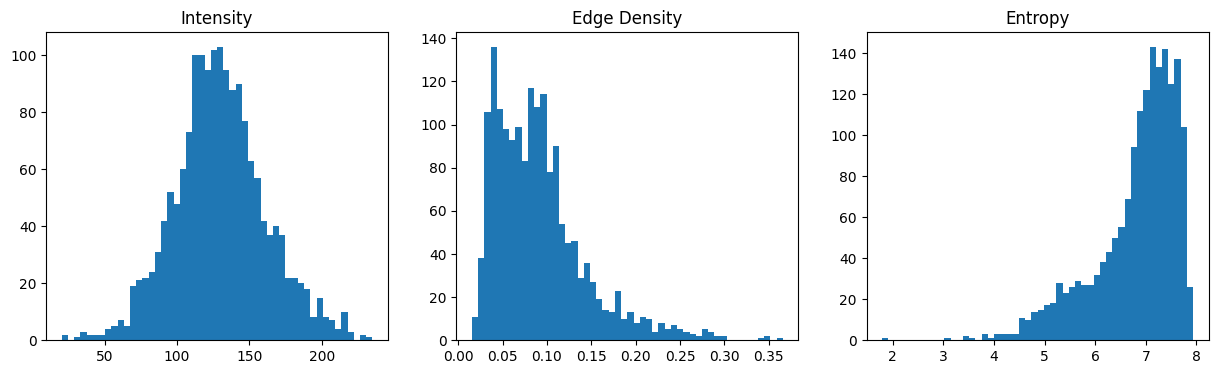

In [24]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(df["intensity"], bins=50)
plt.title("Intensity")

plt.subplot(1,3,2)
plt.hist(df["edge_density"], bins=50)
plt.title("Edge Density")

plt.subplot(1,3,3)
plt.hist(df["entropy"], bins=50)
plt.title("Entropy")

plt.show()

In [25]:
def categorize(row):
    if row["edge_density"] < 0.05:
        return "low"
    elif row["edge_density"] < 0.15:
        return "medium"
    else:
        return "high"

In [26]:
df["category"] = df.apply(categorize, axis=1)

print(df["category"].value_counts())

category
medium    1106
low        393
high       192
Name: count, dtype: int64


In [27]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [28]:
for split in ["train", "test"]:
    for category in ["low", "medium", "high"]:
        for class_name in df["class"].unique():
            
            path = os.path.join(output_path, split, category, class_name)
            os.makedirs(path, exist_ok=True)

In [29]:
def save_images(dataframe, split):
    
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        
        img = cv2.imread(row["path"])
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, (224, 224))

        filename = os.path.basename(row["path"])

        save_dir = os.path.join(
            output_path,
            split,
            row["category"],   # low/medium/high
            row["class"]       # 🔥 FIX: preserve class
        )

        save_path = os.path.join(save_dir, filename)

        cv2.imwrite(save_path, gray)

In [30]:
save_images(train_df, "train")
save_images(test_df, "test")

100%|██████████| 339/339 [00:00<00:00, 967.52it/s] 


In [31]:
df.to_csv("image_features_1.csv", index=False)

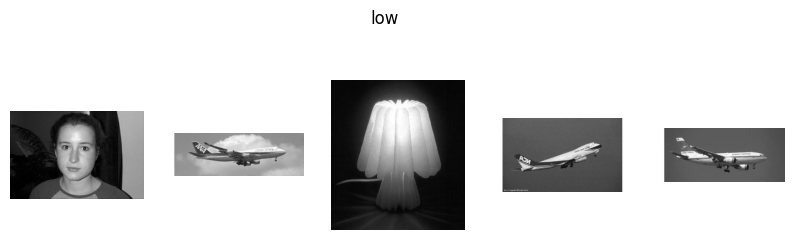

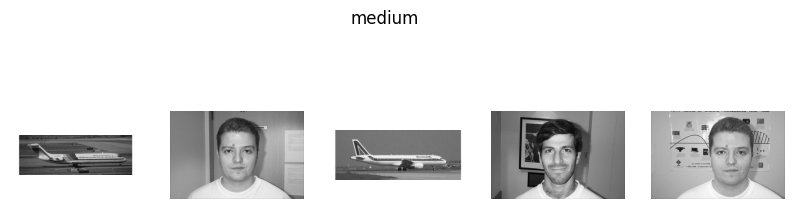

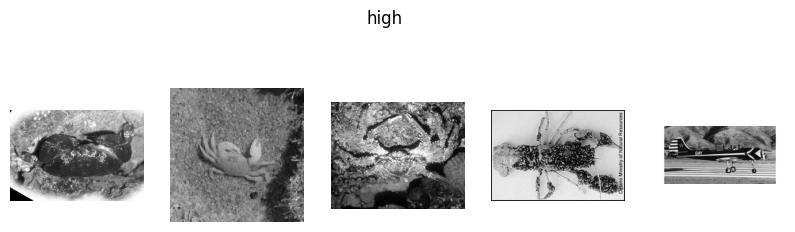

In [32]:
import random
import matplotlib.pyplot as plt

def show_samples(category):
    samples = df[df["category"] == category].sample(5)
    
    plt.figure(figsize=(10,3))
    
    for i, row in enumerate(samples.itertuples()):
        img = cv2.imread(row.path, 0)
        plt.subplot(1,5,i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    
    plt.suptitle(category)
    plt.show()

show_samples("low")
show_samples("medium")
show_samples("high")

In [34]:
print(os.listdir(r"F:\work\python\image frequency\processed_dataset_1\train\low"))

['airplanes', 'barrel', 'beaver', 'camera', 'cellphone', 'crab', 'crayfish', 'crocodile', 'Faces', 'lamp']


In [35]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [36]:
def load_dataset(path):
    return tf.keras.preprocessing.image_dataset_from_directory(
        path,
        image_size=(224, 224),
        batch_size=32,
        color_mode='grayscale',
        label_mode='categorical'
    )

In [37]:
def preprocess(ds):
    ds = ds.map(lambda x, y: (x/255.0, y))
    ds = ds.map(lambda x, y: (tf.image.grayscale_to_rgb(x), y))
    return ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [38]:
low_train = preprocess(load_dataset(r"F:\work\python\image frequency\processed_dataset_1\train\low"))
low_test  = preprocess(load_dataset(r"F:\work\python\image frequency\processed_dataset_1\test\low"))

medium_train = preprocess(load_dataset(r"F:\work\python\image frequency\processed_dataset_1\train\medium"))
medium_test  = preprocess(load_dataset(r"F:\work\python\image frequency\processed_dataset_1\test\medium"))

high_train = preprocess(load_dataset(r"F:\work\python\image frequency\processed_dataset_1\train\high"))
high_test  = preprocess(load_dataset(r"F:\work\python\image frequency\processed_dataset_1\test\high"))

Found 311 files belonging to 10 classes.


Found 82 files belonging to 10 classes.
Found 888 files belonging to 10 classes.
Found 218 files belonging to 10 classes.
Found 153 files belonging to 10 classes.
Found 39 files belonging to 10 classes.


In [39]:
def build_simple_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        layers.MaxPooling2D(),
        
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [40]:
def build_resnet():
    base = tf.keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )
    
    base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation='relu')(x)
    output = layers.Dense(10, activation='softmax')(x)

    model = tf.keras.Model(inputs=base.input, outputs=output)

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [41]:
def build_densenet():
    base = tf.keras.applications.DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )
    
    base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation='relu')(x)
    output = layers.Dense(10, activation='softmax')(x)

    model = tf.keras.Model(inputs=base.input, outputs=output)

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [42]:
def train_model(model, train_ds, test_ds, name):
    
    print(f"\nTraining {name}...\n")
    
    history = model.fit(
        train_ds,
        validation_data=test_ds,
        epochs=10
    )
    
    loss, acc = model.evaluate(test_ds)
    
    return history, acc

In [43]:
cnn_low = build_simple_cnn()
resnet_low = build_resnet()
dense_low = build_densenet()

cnn_low_hist, cnn_low_acc = train_model(cnn_low, low_train, low_test, "CNN Low")
resnet_low_hist, resnet_low_acc = train_model(resnet_low, low_train, low_test, "ResNet Low")
dense_low_hist, dense_low_acc = train_model(dense_low, low_train, low_test, "DenseNet Low")

C:\Users\gopik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step

Training CNN Low...

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 508ms/step - accuracy: 0.6945 - loss: 1.9740 - val_accuracy: 0.8171 - val_loss: 0.8321
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 503ms/step - accuracy: 0.8617 - loss: 0.6243 - val_accuracy: 0.8415 - val_loss: 0.4920
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 531ms/step - accuracy: 0.8939 - loss: 0.3830 - val_accuracy: 0.8415 - val_loss: 0.5668
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 494ms/step - accuracy: 0.8971 - loss: 0.2762 - val_accuracy: 0.9024 - val_loss: 0.4499
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 506ms/step - accuracy: 0.9614 - loss: 0.1804 - val_accuracy: 0.8902 - val_loss: 0.4913
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 525ms/step - accuracy: 0.9904 - loss: 0.0598 - val_accuracy: 0.8780 - val_loss: 0.4961
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 502ms/step - accuracy: 1.0000 - loss: 0.0271 - val_accuracy: 0.8780 - val_loss: 0.6559
Epoch 8/10
10/10 ━━━━━━━━━━━━━

In [44]:
cnn_med = build_simple_cnn()
resnet_med = build_resnet()
dense_med = build_densenet()

cnn_med_hist, cnn_med_acc = train_model(cnn_med, medium_train, medium_test, "CNN Medium")
resnet_med_hist, resnet_med_acc = train_model(resnet_med, medium_train, medium_test, "ResNet Medium")
dense_med_hist, dense_med_acc = train_model(dense_med, medium_train, medium_test, "DenseNet Medium")


Training CNN Medium...

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 496ms/step - accuracy: 0.4606 - loss: 4.5209 - val_accuracy: 0.7477 - val_loss: 0.9751
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 524ms/step - accuracy: 0.8187 - loss: 0.6185 - val_accuracy: 0.7936 - val_loss: 0.6629
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 511ms/step - accuracy: 0.9628 - loss: 0.1475 - val_accuracy: 0.7890 - val_loss: 0.6817
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 502ms/step - accuracy: 0.9955 - loss: 0.0245 - val_accuracy: 0.8073 - val_loss: 0.8437
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 528ms/step - accuracy: 0.9989 - loss: 0.0125 - val_accuracy: 0.7936 - val_loss: 0.8345
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 525ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.7936 - val_loss: 1.0099
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 537ms/step - accuracy: 1.0000 - loss: 5.7299e-04 - val_accuracy: 0.7844 - val_loss: 0.9634
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 577ms/step - accuracy: 1.0

In [45]:
cnn_high = build_simple_cnn()
resnet_high = build_resnet()
dense_high = build_densenet()

cnn_high_hist, cnn_high_acc = train_model(cnn_high, high_train, high_test, "CNN High")
resnet_high_hist, resnet_high_acc = train_model(resnet_high, high_train, high_test, "ResNet High")
dense_high_hist, dense_high_acc = train_model(dense_high, high_train, high_test, "DenseNet High")


Training CNN High...

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 590ms/step - accuracy: 0.1503 - loss: 12.7826 - val_accuracy: 0.2308 - val_loss: 4.3523
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 532ms/step - accuracy: 0.2876 - loss: 2.7045 - val_accuracy: 0.1795 - val_loss: 2.3111
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 557ms/step - accuracy: 0.3529 - loss: 1.9598 - val_accuracy: 0.1795 - val_loss: 2.5460
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 552ms/step - accuracy: 0.4837 - loss: 1.6541 - val_accuracy: 0.2051 - val_loss: 2.0949
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 533ms/step - accuracy: 0.5948 - loss: 1.1821 - val_accuracy: 0.2564 - val_loss: 2.1202
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 542ms/step - accuracy: 0.7974 - loss: 0.6891 - val_accuracy: 0.3846 - val_loss: 2.3201
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 537ms/step - accuracy: 0.9346 - loss: 0.3866 - val_accuracy: 0.3077 - val_loss: 2.3271
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 538ms/step - accuracy: 0.9542 - loss: 0.2121 - val_accu

In [46]:
print("\nFINAL RESULTS\n")

print("LOW:")
print("CNN:", cnn_low_acc)
print("ResNet:", resnet_low_acc)
print("DenseNet:", dense_low_acc)

print("\nMEDIUM:")
print("CNN:", cnn_med_acc)
print("ResNet:", resnet_med_acc)
print("DenseNet:", dense_med_acc)

print("\nHIGH:")
print("CNN:", cnn_high_acc)
print("ResNet:", resnet_high_acc)
print("DenseNet:", dense_high_acc)


FINAL RESULTS

LOW:
CNN: 0.8780487775802612
ResNet: 0.8170731663703918
DenseNet: 0.9756097793579102

MEDIUM:
CNN: 0.7981651425361633
ResNet: 0.7660550475120544
DenseNet: 0.9862385392189026

HIGH:
CNN: 0.41025641560554504
ResNet: 0.28205129504203796
DenseNet: 0.8461538553237915
